Dataset Loaded. Features: 31, Rows: 50000
Predicting initial probabilities for 50000 rows...
Running Counterfactual Search on 50 samples using features: ['time_of_day', 'device_type', 'location', 'age', 'browser', 'OS', 'ad_style_category', 'part_of_add_evaluation_focus_group']
Processing Model A...
Processing Model B...
Analysis Complete. Files saved.

--- PLOTS ---


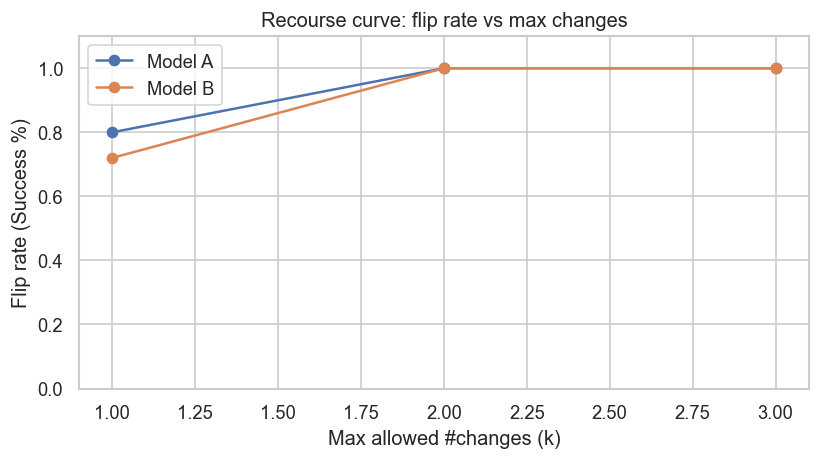

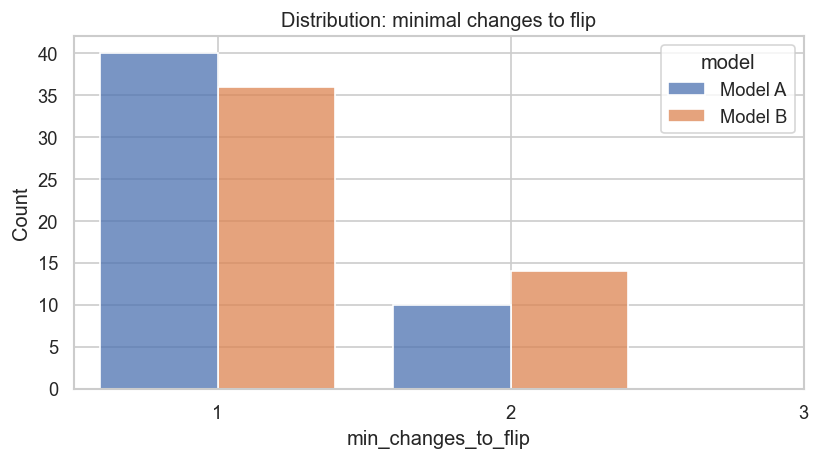

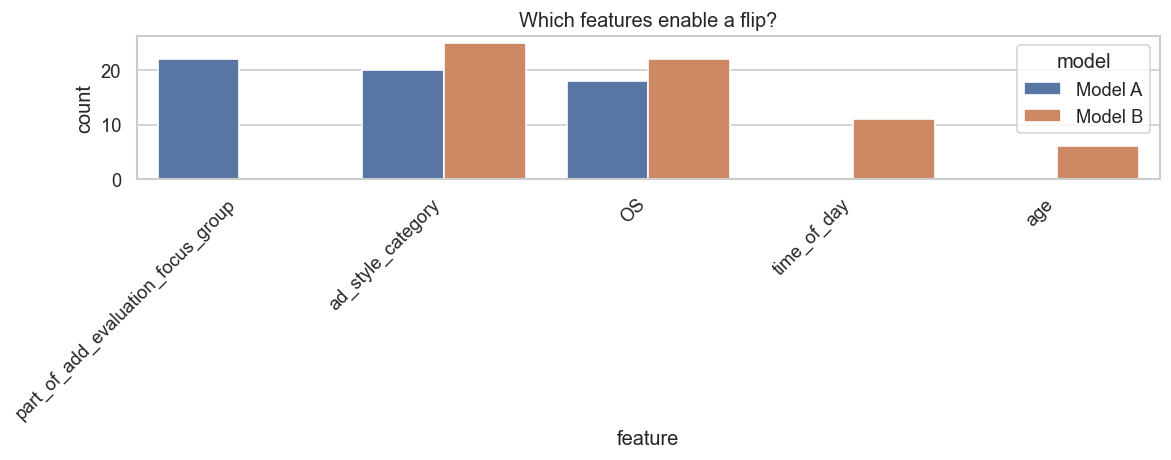

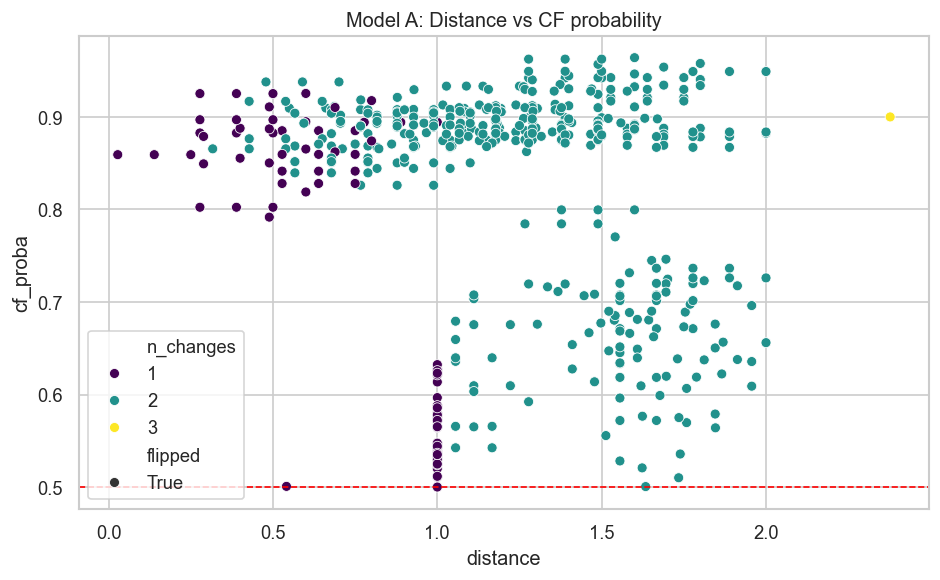

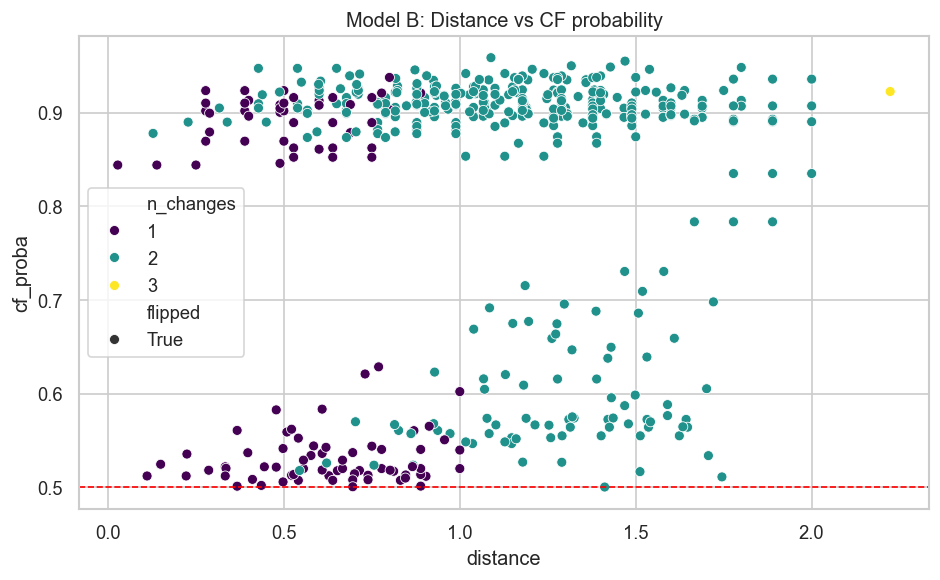


Showing example Counterfactual for Model A...


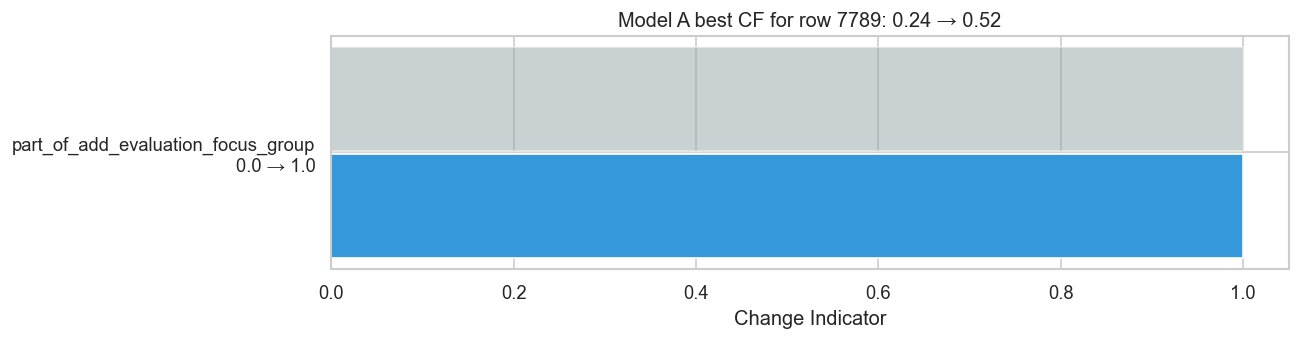


Showing example Counterfactual for Model B...


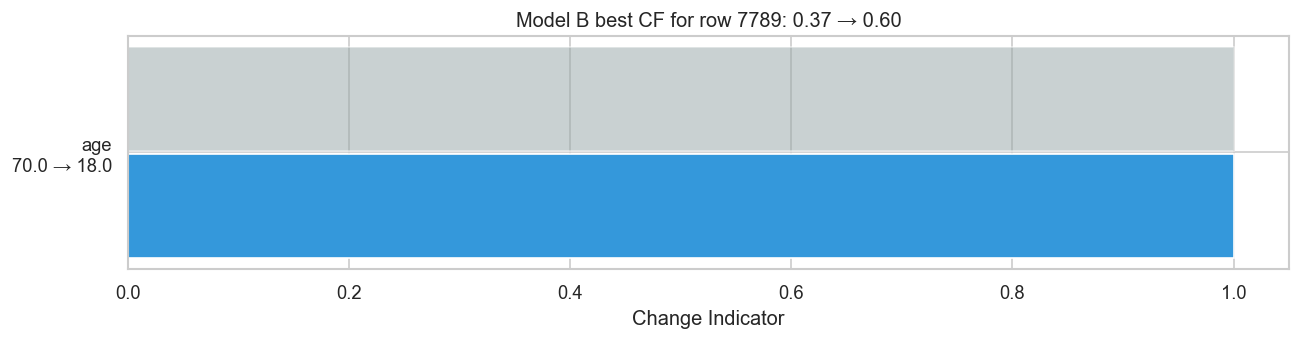


--- SIDE-BY-SIDE COMPARISON ---
Found 50 rows where BOTH models offered recourse.


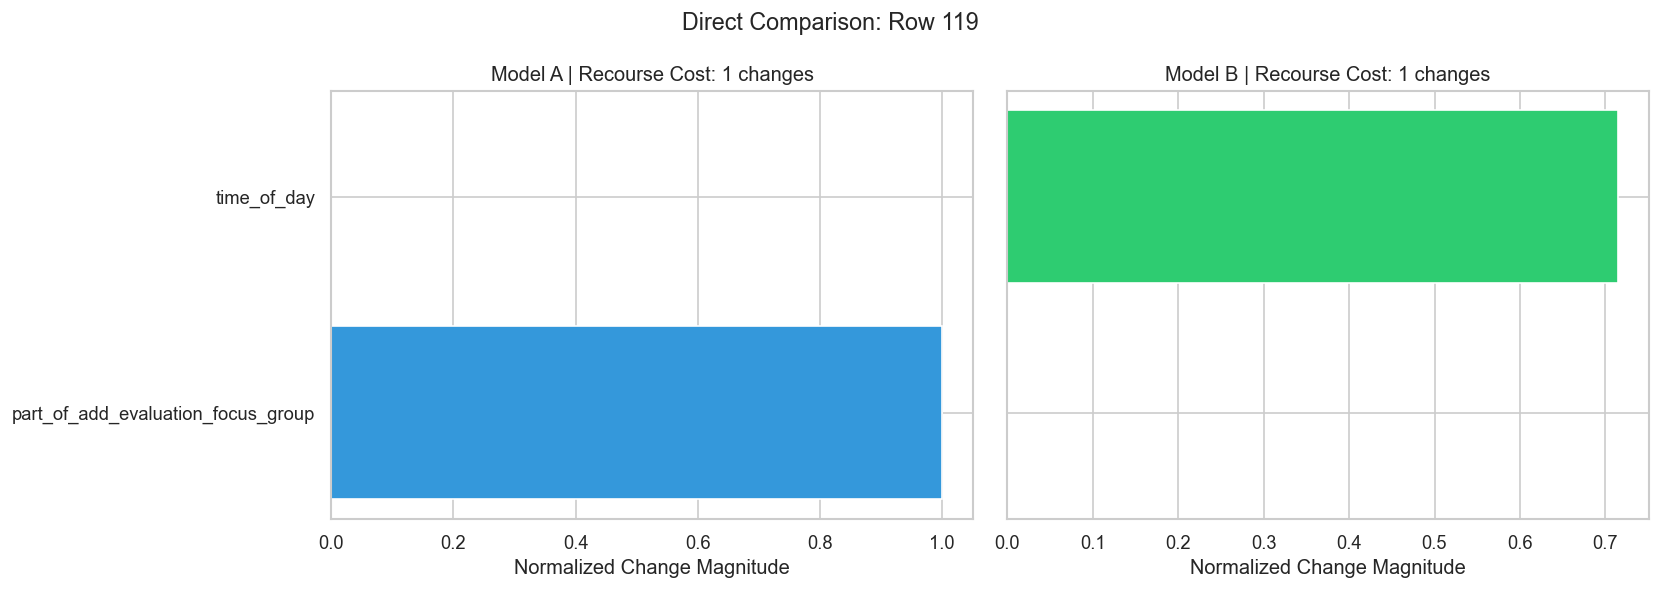

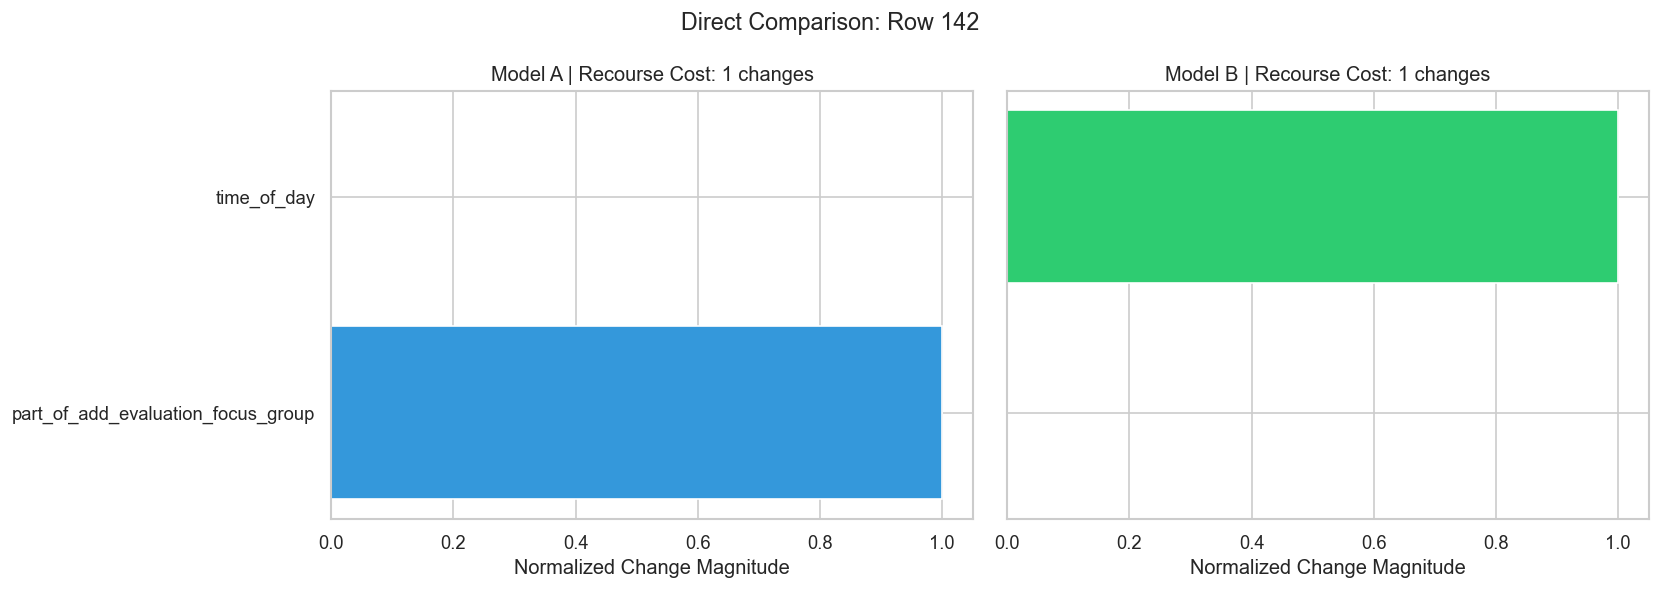

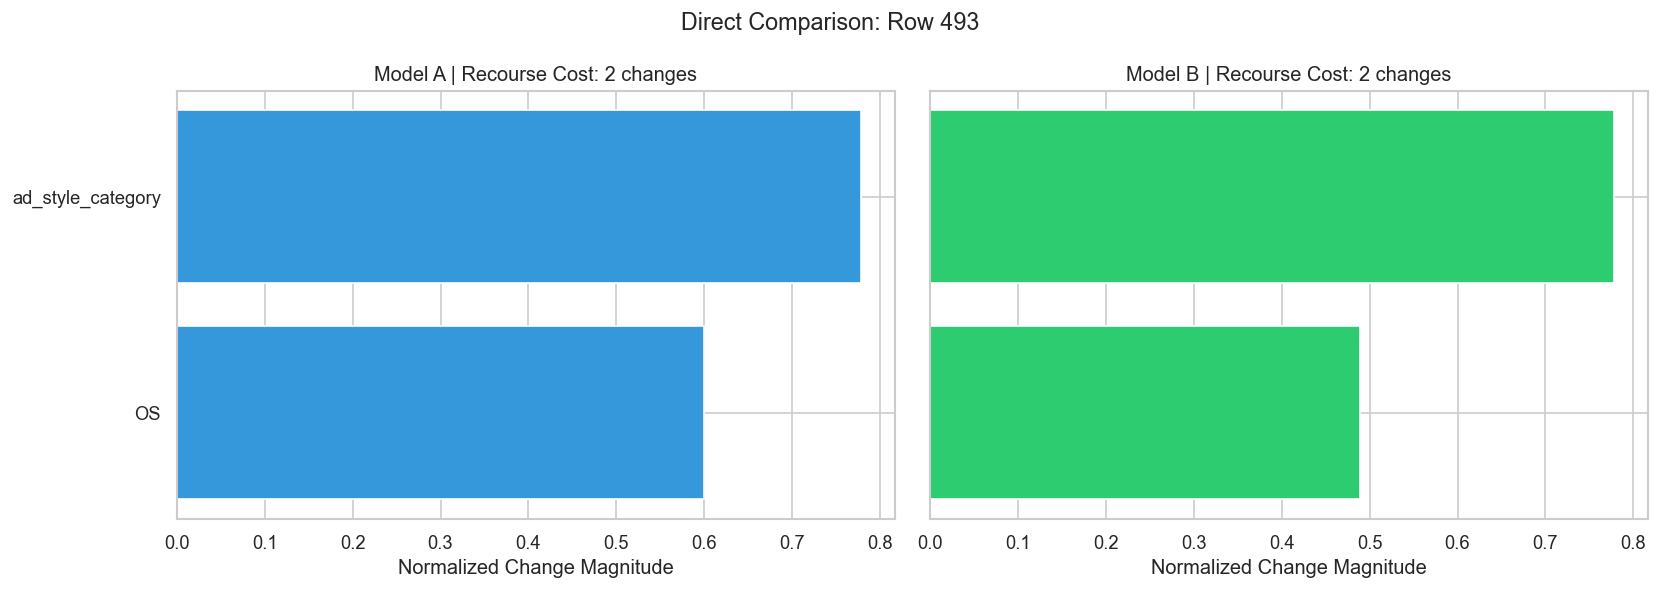

Execution Finished.


In [24]:
import io, csv, os, glob, json
from itertools import combinations, product
from collections import Counter

import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")

# -----------------------------
# CONFIG
# -----------------------------
DATA_FILE = "click_prediction.csv"
MODEL_A_FILE = "add_model_A.json"
MODEL_B_FILE = "add_model_B.json"

TARGET_CANDIDATES = ["clickedonadd", "clicked_on_add", "clicked on add"]

# Columns to drop only if we are treating them as "meta" info not used by model
# NOTE: We keep 'id' in the features matrix because the model expects 32 columns.
DROP_FROM_DATAFRAME = [
    "providedfeedbackaboutadd",
    "rawvisitedgoodsids",
    "rawpurchasedgoodsids",
    "adstylecategoryraw",
    "ad_style_category_raw",
    "visited_goods_ids_raw",
    "purchased_goods_ids_raw",
    "provided_feedback_about_add"
]

THRESHOLD = 0.5

# Exhaustive search controls
MAX_CHANGES = 3
TOP_K_CAT = 12
GRID_NUMERIC = 10
TOP_N_CFS_PER_ROW = 10

# How many rows to evaluate
N_ROWS_TO_EXPLAIN = 50
LOW_PROBA_CUTOFF = 0.4

# Restrict editable features for Counterfactual Search
# CORRECTED LIST: Matches CSV headers exactly
ALLOWED_FEATURES = [
    "time_of_day", 
    "device_type", 
    "location", 
    "age", 
    "browser", 
    "OS", 
    "ad_style_category", 
    "part_of_add_evaluation_focus_group"
]

# Fairness plotting controls
N_SIDE_BY_SIDE = 3  # how many common rows to show side-by-side


# -----------------------------
# 1) Robust CSV loading
# -----------------------------
def _clean_lines(path: str) -> str:
    """Reads file, skipping empty lines or separator lines (---)."""
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        kept = []
        for ln in f:
            s = ln.rstrip("\n")
            if not s.strip():
                continue
            if set(s.strip()) == {"-"}:
                continue
            kept.append(s)
    return "\n".join(kept)

def load_dataset(path: str) -> pd.DataFrame:
    text = _clean_lines(path)
    # Sniff separator
    sample = "\n".join(text.splitlines()[:10])
    try:
        sep = csv.Sniffer().sniff(sample, delimiters=[",", ";", "\t", "|"]).delimiter
    except Exception:
        sep = None

    df = pd.read_csv(io.StringIO(text), sep=sep, engine="python")
    # Clean column names
    df.columns = [str(c).strip() for c in df.columns]
    return df

def pick_target_column(df: pd.DataFrame):
    cols = set(df.columns)
    for c in TARGET_CANDIDATES:
        if c in cols:
            return c
    raise ValueError(f"Target not found. Tried: {TARGET_CANDIDATES}. Available: {list(df.columns)}")

if not os.path.exists(DATA_FILE):
    raise FileNotFoundError(f"Missing {DATA_FILE}. Please upload it.")

df = load_dataset(DATA_FILE)
TARGET_COL = pick_target_column(df)

# Prepare Feature Matrix X and Target y
# We drop the target and specific "raw" string columns not used by the model
cols_to_drop = [c for c in DROP_FROM_DATAFRAME + [TARGET_COL] if c in df.columns]
X_raw = df.drop(columns=cols_to_drop).copy()
y = df[TARGET_COL].astype(int)

print(f"Dataset Loaded. Features: {X_raw.shape[1]}, Rows: {X_raw.shape[0]}")


# -----------------------------
# 2) Encode everything to numeric float32
# -----------------------------
def build_category_maps(X: pd.DataFrame):
    maps = {}
    for col in X.columns:
        if not pd.api.types.is_numeric_dtype(X[col]):
            vals = X[col].astype(str).fillna("NA")
            cats = pd.Index(vals.unique()).tolist()
            maps[col] = {v: i for i, v in enumerate(cats)}
    return maps

def encode_with_maps(X: pd.DataFrame, maps: dict) -> pd.DataFrame:
    Xe = X.copy()
    for col, m in maps.items():
        if col in Xe.columns:
            Xe[col] = Xe[col].astype(str).fillna("NA").map(m).fillna(-1).astype(int)
    
    # Force all to float32 for XGBoost
    Xe = Xe.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return Xe.astype(np.float32)

cat_maps = build_category_maps(X_raw)
X = encode_with_maps(X_raw, cat_maps)

# For distance normalization (MAD / Range)
col_min = X.min(axis=0)
col_max = X.max(axis=0)
col_rng = (col_max - col_min).replace(0, 1.0)


# -----------------------------
# 3) Load both models
# -----------------------------
def load_booster(path: str) -> xgb.Booster:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing model: {path}")
    b = xgb.Booster()
    b.load_model(path)
    return b

modelA = load_booster(MODEL_A_FILE)
modelB = load_booster(MODEL_B_FILE)

# Validation check for feature count
if modelA.num_features() != X.shape[1]:
    print(f"WARNING: Model A expects {modelA.num_features()} features, but dataset has {X.shape[1]}.")
else:
    print(f"Model A & B expect {modelA.num_features()} features. Dataset matches.")

def predict_proba(booster: xgb.Booster, X_enc: pd.DataFrame) -> np.ndarray:
    return booster.predict(xgb.DMatrix(X_enc.to_numpy()))


# -----------------------------
# 4) Candidate pools (finite grid)
# -----------------------------
def candidate_pool_for_col(col: str, X_raw_full: pd.DataFrame, X_enc_full: pd.DataFrame, 
                           cat_maps: dict, top_k_cat: int, grid_numeric: int) -> np.ndarray:
    # If categorical (in map), pick most common values
    if col in cat_maps:
        common_vals = (
            X_raw_full[col].astype(str).fillna("NA")
            .value_counts().head(top_k_cat).index.tolist()
        )
        m = cat_maps[col]
        pool = sorted(set(float(m.get(v, -1)) for v in common_vals))
        return np.array(pool, dtype=np.float32)

    # If numeric, create a grid
    mn = float(X_enc_full[col].min())
    mx = float(X_enc_full[col].max())
    if np.isclose(mn, mx):
        return np.array([mn], dtype=np.float32)
    return np.linspace(mn, mx, grid_numeric).astype(np.float32)

def decode_val(col: str, enc_val: float) -> str:
    if col not in cat_maps:
        return str(round(enc_val, 2))
    inv = {v: k for k, v in cat_maps[col].items()}
    return inv.get(int(enc_val), f"code={int(enc_val)}")


# -----------------------------
# 5) Exhaustive search returning TOP-N CFs
# -----------------------------
def enumerate_counterfactuals_topN(
    booster: xgb.Booster,
    instance_idx: int,
    X_raw_full: pd.DataFrame,
    X_enc_full: pd.DataFrame,
    allowed_features,
    threshold: float,
    max_changes: int,
    top_k_cat: int,
    grid_numeric: int,
    top_n: int,
):
    inst_raw = X_raw_full.iloc[instance_idx]
    inst_enc = X_enc_full.iloc[instance_idx].copy()

    # Filter allowed features to those actually in columns
    allowed = [c for c in allowed_features if c in X_enc_full.columns]
    
    # Build candidate pools
    pools = {c: candidate_pool_for_col(c, X_raw_full, X_enc_full, cat_maps, top_k_cat, grid_numeric) for c in allowed}
    pools = {c: p for c, p in pools.items() if len(p) > 0}
    
    if not pools:
        return None, None

    # Base Probability
    base_prob = float(booster.predict(xgb.DMatrix(pd.DataFrame([inst_enc]).to_numpy()))[0])
    base_norm = (inst_enc - col_min) / col_rng

    records = []

    # Iterate 1 to k changes
    for k in range(1, max_changes + 1):
        for feat_subset in combinations(list(pools.keys()), k):
            value_lists = [pools[f] for f in feat_subset]

            cand_rows = []
            cand_changes = []
            
            # Cartesian product of values for the selected subset
            for vals in product(*value_lists):
                cf = inst_enc.copy()
                changes = {}
                changed_any = False
                
                for f, v in zip(feat_subset, vals):
                    # Only if value is actually different
                    if float(cf[f]) != float(v):
                        changes[f] = (float(inst_enc[f]), float(v))
                        cf[f] = float(v)
                        changed_any = True
                
                if changed_any:
                    cand_rows.append(cf)
                    cand_changes.append(changes)

            if not cand_rows:
                continue

            # Batch prediction
            cand_df = pd.DataFrame(cand_rows).astype(np.float32)
            probs = booster.predict(xgb.DMatrix(cand_df.to_numpy()))

            # Distance calculation (Manhattan on normalized data)
            cand_norm = (cand_df - col_min) / col_rng
            distances = np.abs(cand_norm.to_numpy() - base_norm.to_numpy()).sum(axis=1)

            for i in range(len(cand_df)):
                p = float(probs[i])
                flipped = bool(p >= threshold)
                
                records.append({
                    "row_idx": int(instance_idx),
                    "orig_proba": base_prob,
                    "cf_proba": p,
                    "flipped": flipped,
                    "n_changes": k,
                    "distance": float(distances[i]),
                    "changes_encoded": cand_changes[i],  # dict col -> (old_enc, new_enc)
                })

    if not records:
        return base_prob, pd.DataFrame()

    df_cf = pd.DataFrame(records)

    # Sort: Flipped first, then fewer changes, then higher prob, then lower distance
    df_cf = df_cf.sort_values(
        by=["flipped", "n_changes", "cf_proba", "distance"],
        ascending=[False, True, False, True]
    ).head(top_n).reset_index(drop=True)

    # Decode changes for human readability
    def decode_changes(chdict):
        out = {}
        for c, (old_e, new_e) in chdict.items():
            if c in cat_maps:
                out[c] = (decode_val(c, old_e), decode_val(c, new_e))
            else:
                out[c] = (float(inst_raw.get(c, old_e)), float(new_e))
        return out

    df_cf["changes"] = df_cf["changes_encoded"].apply(decode_changes)
    return base_prob, df_cf


# -----------------------------
# 6) Plot helpers
# -----------------------------
def plot_individual_cf_bars(best_cf_row, title):
    if best_cf_row is None or not best_cf_row.get("changes"):
        print(f"{title}: no CF")
        return
    changes = best_cf_row["changes"]
    feats = list(changes.keys())
    old_vals = [changes[f][0] for f in feats]
    new_vals = [changes[f][1] for f in feats]

    y = np.arange(len(feats))
    plt.figure(figsize=(11, max(3, len(feats) * 0.7)))

    old_plot, new_plot, labels = [], [], []
    for f, o, n in zip(feats, old_vals, new_vals):
        # Stringify if categorical for labels
        old_plot.append(0.0); new_plot.append(1.0) # Dummy length for viz
        labels.append(f"{f}\n{o} → {n}")

    plt.barh(y + 0.18, [1]*len(y), 0.35, label="Original", color="#95a5a6", alpha=0.5)
    plt.barh(y - 0.18, [1]*len(y), 0.35, label="Counterfactual", color="#3498db")
    plt.yticks(y, labels)
    plt.title(title)
    plt.xlabel("Change Indicator")
    plt.tight_layout()
    plt.show()

def plot_tradeoff_scatter(cf_long_df, model_name):
    if cf_long_df.empty:
        return
    plt.figure(figsize=(8, 5))
    sns.scatterplot(
        data=cf_long_df,
        x="distance",
        y="cf_proba",
        hue="n_changes",
        style="flipped",
        palette="viridis"
    )
    plt.axhline(THRESHOLD, color="red", linestyle="--", linewidth=1)
    plt.title(f"{model_name}: Distance vs CF probability")
    plt.tight_layout()
    plt.show()

def plot_flip_rate_curve(min_k_df, title):
    plt.figure(figsize=(7, 4))
    for model_name, grp in min_k_df.groupby("model"):
        rates = []
        for k in range(1, MAX_CHANGES + 1):
            rate = np.mean(grp["min_changes_to_flip"].notna() & (grp["min_changes_to_flip"] <= k))
            rates.append(rate)
        plt.plot(range(1, MAX_CHANGES + 1), rates, marker="o", label=model_name)
    plt.ylim(0, 1.1)
    plt.xlabel("Max allowed #changes (k)")
    plt.ylabel("Flip rate (Success %)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_min_changes_hist(min_k_df, title):
    plt.figure(figsize=(7, 4))
    sns.histplot(
        data=min_k_df,
        x="min_changes_to_flip",
        hue="model",
        discrete=True,
        multiple="dodge",
        shrink=0.8
    )
    plt.xticks(range(1, MAX_CHANGES + 1))
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_feature_frequency(feature_freq_df, title):
    if feature_freq_df.empty:
        return
    plt.figure(figsize=(10, 4))
    sns.barplot(data=feature_freq_df, x="feature", y="count", hue="model")
    plt.xticks(rotation=45, ha="right")
    plt.title(title)
    plt.tight_layout()
    plt.show()


# ----------------------------
# FAIRNESS HELPERS
# ----------------------------
def pick_first_existing(df, candidates, required=True):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"None of these columns exist: {candidates}. Available: {list(df.columns)}")
    return None

def infer_cf_found(df):
    if "cf_found" in df.columns:
        return df["cf_found"].astype(bool)
    if "min_changes_to_flip" in df.columns:
        return df["min_changes_to_flip"].notna()
    raise KeyError("Could not infer CF success.")

def find_first_file(patterns):
    for pat in patterns:
        hits = sorted(glob.glob(pat))
        if hits:
            return hits[0]
    return None


# -----------------------------
# 7) Run: generate CFs for many rows + save + plots
# -----------------------------
print(f"Predicting initial probabilities for {len(X)} rows...")
probaA = predict_proba(modelA, X)
probaB = predict_proba(modelB, X)

# Select candidates: rows where BOTH models predict Negative (No Click)
low_mask = (probaA < LOW_PROBA_CUTOFF) & (probaB < LOW_PROBA_CUTOFF)
candidate_idxs = np.where(low_mask)[0]

if len(candidate_idxs) < N_ROWS_TO_EXPLAIN:
    print(f"Not enough common negatives. Using {len(candidate_idxs)} and padding with lowest average prob.")
    avg = (probaA + probaB) / 2.0
    candidate_idxs = np.argsort(avg)[:N_ROWS_TO_EXPLAIN]
else:
    # Shuffle or pick first N
    np.random.shuffle(candidate_idxs)
    candidate_idxs = candidate_idxs[:N_ROWS_TO_EXPLAIN]

print(f"Running Counterfactual Search on {len(candidate_idxs)} samples using features: {ALLOWED_FEATURES}")

all_cf_long = []
min_k_rows = []
feature_counter = Counter()

# Per-feature LONG table for the *best flipped CF* per row+model
best_long_records = []

for model_name, booster, proba in [("Model A", modelA, probaA), ("Model B", modelB, probaB)]:
    print(f"Processing {model_name}...")
    for idx in candidate_idxs:
        base_prob, top_df = enumerate_counterfactuals_topN(
            booster=booster,
            instance_idx=int(idx),
            X_raw_full=X_raw,
            X_enc_full=X,
            allowed_features=ALLOWED_FEATURES,
            threshold=THRESHOLD,
            max_changes=MAX_CHANGES,
            top_k_cat=TOP_K_CAT,
            grid_numeric=GRID_NUMERIC,
            top_n=TOP_N_CFS_PER_ROW
        )

        if top_df is None or top_df.empty:
            min_k_rows.append({"row_idx": int(idx), "model": model_name, "min_changes_to_flip": np.nan})
            continue

        # Save top-N long-format rows for scatter/trade-off plots
        for _, r in top_df.iterrows():
            all_cf_long.append({
                "model": model_name,
                "row_idx": int(r["row_idx"]),
                "orig_proba": float(r["orig_proba"]),
                "cf_proba": float(r["cf_proba"]),
                "flipped": bool(r["flipped"]),
                "n_changes": int(r["n_changes"]),
                "distance": float(r["distance"]),
                # CSV-safe: store as JSON string
                "changes_json": json.dumps(r["changes"], ensure_ascii=False),
            })

        # Minimal changes to flip
        flipped_df = top_df[top_df["flipped"] == True]
        if flipped_df.empty:
            min_k_rows.append({"row_idx": int(idx), "model": model_name, "min_changes_to_flip": np.nan})
            continue

        # Best flipped CF
        best_flip = flipped_df.sort_values(
            ["n_changes", "cf_proba", "distance"],
            ascending=[True, False, True]
        ).iloc[0]

        kmin = int(best_flip["n_changes"])
        min_k_rows.append({"row_idx": int(idx), "model": model_name, "min_changes_to_flip": kmin})

        # Count features used
        for f in best_flip["changes"].keys():
            feature_counter[(model_name, f)] += 1

        # Build per-feature abs change table
        changes_encoded = best_flip["changes_encoded"]  # dict f -> (old_enc, new_enc)
        for f, (old_e, new_e) in changes_encoded.items():
            rng = float(col_rng.get(f, 1.0))
            best_long_records.append({
                "model": model_name,
                "row_idx": int(idx),
                "feature": f,
                "old_enc": float(old_e),
                "new_enc": float(new_e),
                "abs_change": float(abs(new_e - old_e)),
                "abs_change_norm": float(abs(new_e - old_e) / (rng if rng != 0 else 1.0)),
                "n_changes": kmin,
                "orig_proba": float(best_flip["orig_proba"]),
                "cf_proba": float(best_flip["cf_proba"]),
            })

# DataFrames for outputs
cf_long_df = pd.DataFrame(all_cf_long)
min_k_df = pd.DataFrame(min_k_rows)
best_cf_long_df = pd.DataFrame(best_long_records)
feature_freq_df = pd.DataFrame([
    {"model": m, "feature": f, "count": c} 
    for (m, f), c in feature_counter.items()
]).sort_values(["model", "count"], ascending=[True, False])

# Save files
best_cf_long_df.to_csv("cf_best_long_modelA_modelB.csv", index=False)
cf_long_df.to_csv("cf_topN_long_modelA_modelB.csv", index=False)
min_k_df.to_csv("cf_min_changes_modelA_modelB.csv", index=False)
feature_freq_df.to_csv("cf_feature_frequency_modelA_modelB.csv", index=False)

print("Analysis Complete. Files saved.")


# -----------------------------
# 8) Presentation plots
# -----------------------------
print("\n--- PLOTS ---")
plot_flip_rate_curve(min_k_df, "Recourse curve: flip rate vs max changes")
plot_min_changes_hist(min_k_df, "Distribution: minimal changes to flip")
plot_feature_frequency(feature_freq_df, "Which features enable a flip?")

# Tradeoff Plots
for m in ["Model A", "Model B"]:
    plot_tradeoff_scatter(cf_long_df[cf_long_df["model"] == m].copy(), m)

# Individual examples
for m in ["Model A", "Model B"]:
    sub = cf_long_df[(cf_long_df["model"] == m) & (cf_long_df["flipped"] == True)]
    if sub.empty: continue
    
    print(f"\nShowing example Counterfactual for {m}...")
    # Pick the best CF for the first available row
    ridx = sub["row_idx"].iloc[0]
    s2 = sub[sub["row_idx"] == ridx].sort_values(["n_changes", "cf_proba"], ascending=[True, False]).iloc[0].to_dict()
    s2["changes"] = json.loads(s2["changes_json"])
    plot_individual_cf_bars(
        s2,
        title=f"{m} best CF for row {ridx}: {s2['orig_proba']:.2f} → {s2['cf_proba']:.2f}"
    )


# ----------------------------
# 9) SIDE-BY-SIDE FAIRNESS COMPARISON
# ----------------------------
print("\n--- SIDE-BY-SIDE COMPARISON ---")

# Reload data to ensure clean state
min_k_df2 = pd.read_csv("cf_min_changes_modelA_modelB.csv")
best_cf_long_df2 = pd.read_csv("cf_best_long_modelA_modelB.csv")

# Identify rows flipped by BOTH models
flipped_rows = min_k_df2[min_k_df2["min_changes_to_flip"].notna()]
common_counts = flipped_rows.groupby("row_idx")["model"].nunique()
common_row_idxs = common_counts[common_counts >= 2].index.tolist()

print(f"Found {len(common_row_idxs)} rows where BOTH models offered recourse.")

# Plot Side-by-Side
rows_to_plot = common_row_idxs[:N_SIDE_BY_SIDE]
models_order = ["Model A", "Model B"]

for ridx in rows_to_plot:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    if len(models_order) == 1: axes = [axes]

    for ax, m in zip(axes, models_order):
        # Get metadata
        summ = min_k_df2[(min_k_df2["row_idx"] == ridx) & (min_k_df2["model"] == m)]
        if summ.empty:
            ax.set_title(f"{m} (No Result)")
            ax.axis("off")
            continue
        
        changes = summ.iloc[0]["min_changes_to_flip"]
        
        # Get feature deltas
        deltas = best_cf_long_df2[
            (best_cf_long_df2["row_idx"] == ridx) & 
            (best_cf_long_df2["model"] == m)
        ].sort_values("abs_change_norm", ascending=True)

        if deltas.empty:
            ax.set_title(f"{m} | {int(changes)} changes\n(No data)")
            continue

        ax.barh(deltas["feature"], deltas["abs_change_norm"], color="#2ecc71" if m == "Model B" else "#3498db")
        ax.set_title(f"{m} | Recourse Cost: {changes} changes")
        ax.set_xlabel("Normalized Change Magnitude")

    fig.suptitle(f"Direct Comparison: Row {ridx}", fontsize=14)
    plt.tight_layout()
    plt.show()

print("Execution Finished.")

Running Analysis...
Processing Model A...
Processing Model B...


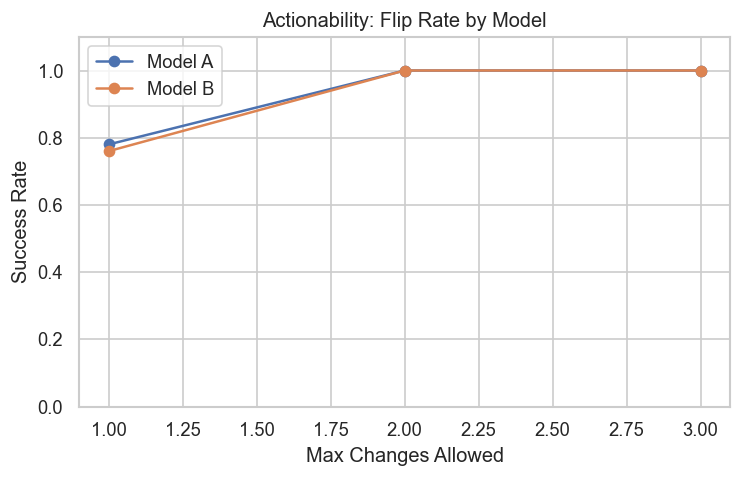

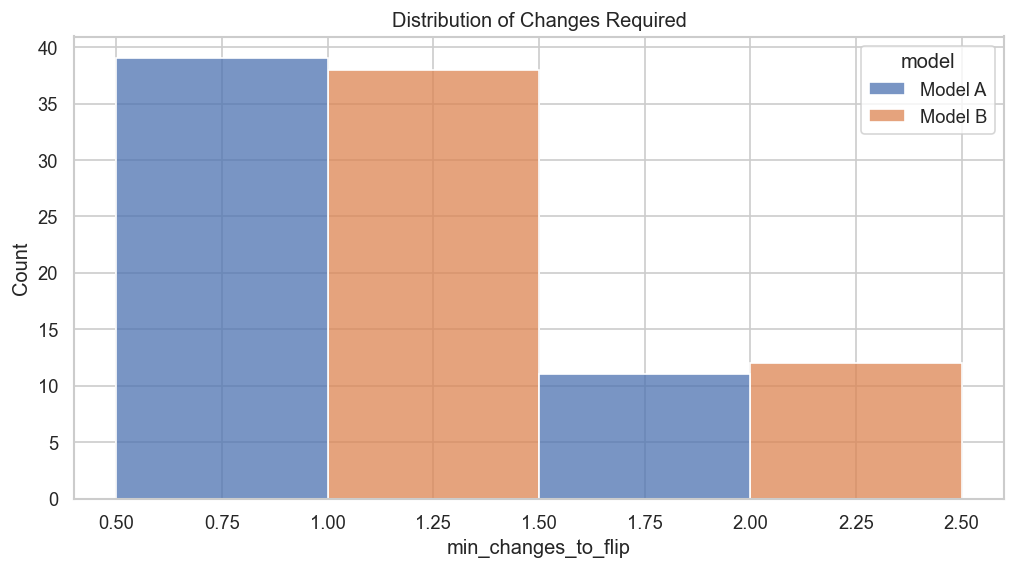


FINAL EVALUATION RESULT
Model A: Success Rate = 100.0%, Avg Cost = 0.7939
Model B: Success Rate = 100.0%, Avg Cost = 0.6151
----------------------------------------
CONCLUSION: The Best Model is **Model B**.
REASONING: Model B is chosen because while both models have similar success rates, Model B requires smaller, more realistic changes (Cost: 0.62 vs 0.79). This makes the suggested interventions easier to implement.


In [25]:
import io, csv, os, glob, json
from itertools import combinations, product
from collections import Counter

import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")

# -----------------------------
# CONFIGURATION
# -----------------------------
DATA_FILE = "click_prediction.csv"
MODEL_A_FILE = "add_model_A.json"
MODEL_B_FILE = "add_model_B.json"

TARGET_CANDIDATES = ["clickedonadd", "clicked_on_add", "clicked on add"]

# Columns to drop (Metadata not used by the model)
DROP_FROM_DATAFRAME = [
    "providedfeedbackaboutadd",
    "rawvisitedgoodsids",
    "rawpurchasedgoodsids",
    "adstylecategoryraw",
    "ad_style_category_raw",
    "visited_goods_ids_raw",
    "purchased_goods_ids_raw",
    "provided_feedback_about_add"
]

THRESHOLD = 0.5

# Search Parameters
MAX_CHANGES = 3
TOP_K_CAT = 12
GRID_NUMERIC = 10
TOP_N_CFS_PER_ROW = 10
N_ROWS_TO_EXPLAIN = 50
LOW_PROBA_CUTOFF = 0.4

# Actionable Features (Must match CSV headers exactly)
ALLOWED_FEATURES = [
    "time_of_day", 
    "device_type", 
    "location", 
    "age", 
    "browser", 
    "OS", 
    "ad_style_category", 
    "part_of_add_evaluation_focus_group"
]

# -----------------------------
# 1) Robust CSV loading
# -----------------------------
def _clean_lines(path: str) -> str:
    """Reads file, skipping empty lines or separator lines (---)."""
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        kept = []
        for ln in f:
            s = ln.rstrip("\n")
            if not s.strip(): continue
            if set(s.strip()) == {"-"}: continue
            kept.append(s)
    return "\n".join(kept)

def load_dataset(path: str) -> pd.DataFrame:
    text = _clean_lines(path)
    # Sniff separator
    sample = "\n".join(text.splitlines()[:10])
    try:
        sep = csv.Sniffer().sniff(sample, delimiters=[",", ";", "\t", "|"]).delimiter
    except Exception:
        sep = None
    df = pd.read_csv(io.StringIO(text), sep=sep, engine="python")
    df.columns = [str(c).strip() for c in df.columns]
    return df

def pick_target_column(df: pd.DataFrame):
    cols = set(df.columns)
    for c in TARGET_CANDIDATES:
        if c in cols: return c
    raise ValueError(f"Target not found. Tried: {TARGET_CANDIDATES}")

if not os.path.exists(DATA_FILE):
    raise FileNotFoundError(f"Missing {DATA_FILE}. Please upload it.")

df = load_dataset(DATA_FILE)
TARGET_COL = pick_target_column(df)

cols_to_drop = [c for c in DROP_FROM_DATAFRAME + [TARGET_COL] if c in df.columns]
X_raw = df.drop(columns=cols_to_drop).copy()
y = df[TARGET_COL].astype(int)

# -----------------------------
# 2) Encode Data
# -----------------------------
def build_category_maps(X: pd.DataFrame):
    maps = {}
    for col in X.columns:
        if not pd.api.types.is_numeric_dtype(X[col]):
            vals = X[col].astype(str).fillna("NA")
            cats = pd.Index(vals.unique()).tolist()
            maps[col] = {v: i for i, v in enumerate(cats)}
    return maps

def encode_with_maps(X: pd.DataFrame, maps: dict) -> pd.DataFrame:
    Xe = X.copy()
    for col, m in maps.items():
        if col in Xe.columns:
            Xe[col] = Xe[col].astype(str).fillna("NA").map(m).fillna(-1).astype(int)
    Xe = Xe.apply(pd.to_numeric, errors="coerce").fillna(0.0)
    return Xe.astype(np.float32)

cat_maps = build_category_maps(X_raw)
X = encode_with_maps(X_raw, cat_maps)

col_min = X.min(axis=0)
col_max = X.max(axis=0)
col_rng = (col_max - col_min).replace(0, 1.0)

# -----------------------------
# 3) Load Models
# -----------------------------
def load_booster(path: str) -> xgb.Booster:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing model: {path}")
    b = xgb.Booster()
    b.load_model(path)
    return b

modelA = load_booster(MODEL_A_FILE)
modelB = load_booster(MODEL_B_FILE)

# -----------------------------
# 4) Candidate Pools
# -----------------------------
def candidate_pool_for_col(col, X_raw_full, X_enc_full, cat_maps, top_k_cat, grid_numeric):
    if col in cat_maps:
        common_vals = X_raw_full[col].astype(str).fillna("NA").value_counts().head(top_k_cat).index.tolist()
        m = cat_maps[col]
        pool = sorted(set(float(m.get(v, -1)) for v in common_vals))
        return np.array(pool, dtype=np.float32)
    mn, mx = float(X_enc_full[col].min()), float(X_enc_full[col].max())
    if np.isclose(mn, mx): return np.array([mn], dtype=np.float32)
    return np.linspace(mn, mx, grid_numeric).astype(np.float32)

def decode_val(col, enc_val):
    if col not in cat_maps: return str(round(enc_val, 2))
    inv = {v: k for k, v in cat_maps[col].items()}
    return inv.get(int(enc_val), f"code={int(enc_val)}")

# -----------------------------
# 5) Exhaustive Search
# -----------------------------
def enumerate_counterfactuals_topN(booster, instance_idx, X_raw_full, X_enc_full, allowed_features, threshold, max_changes, top_k_cat, grid_numeric, top_n):
    inst_enc = X_enc_full.iloc[instance_idx].copy()
    inst_raw = X_raw_full.iloc[instance_idx]
    
    allowed = [c for c in allowed_features if c in X_enc_full.columns]
    pools = {c: candidate_pool_for_col(c, X_raw_full, X_enc_full, cat_maps, top_k_cat, grid_numeric) for c in allowed}
    pools = {c: p for c, p in pools.items() if len(p) > 0}
    
    base_prob = float(booster.predict(xgb.DMatrix(pd.DataFrame([inst_enc]).to_numpy()))[0])
    base_norm = (inst_enc - col_min) / col_rng
    
    records = []
    
    for k in range(1, max_changes + 1):
        for feat_subset in combinations(list(pools.keys()), k):
            value_lists = [pools[f] for f in feat_subset]
            cand_rows, cand_changes = [], []
            
            for vals in product(*value_lists):
                cf = inst_enc.copy()
                changes = {}
                changed_any = False
                for f, v in zip(feat_subset, vals):
                    if float(cf[f]) != float(v):
                        changes[f] = (float(inst_enc[f]), float(v))
                        cf[f] = float(v)
                        changed_any = True
                if changed_any:
                    cand_rows.append(cf)
                    cand_changes.append(changes)
            
            if not cand_rows: continue
            
            cand_df = pd.DataFrame(cand_rows).astype(np.float32)
            probs = booster.predict(xgb.DMatrix(cand_df.to_numpy()))
            cand_norm = (cand_df - col_min) / col_rng
            distances = np.abs(cand_norm.to_numpy() - base_norm.to_numpy()).sum(axis=1)
            
            for i in range(len(cand_df)):
                p = float(probs[i])
                records.append({
                    "row_idx": int(instance_idx),
                    "orig_proba": base_prob,
                    "cf_proba": p,
                    "flipped": bool(p >= threshold),
                    "n_changes": k,
                    "distance": float(distances[i]),
                    "changes_encoded": cand_changes[i]
                })

    if not records: return base_prob, pd.DataFrame()
    
    df_cf = pd.DataFrame(records)
    df_cf = df_cf.sort_values(by=["flipped", "n_changes", "cf_proba", "distance"], ascending=[False, True, False, True]).head(top_n)
    
    def decode_changes(chdict):
        out = {}
        for c, (old_e, new_e) in chdict.items():
            if c in cat_maps: out[c] = (decode_val(c, old_e), decode_val(c, new_e))
            else: out[c] = (float(inst_raw.get(c, old_e)), float(new_e))
        return out
    
    df_cf["changes"] = df_cf["changes_encoded"].apply(decode_changes)
    return base_prob, df_cf

# -----------------------------
# 6) Plotting Functions
# -----------------------------
def plot_flip_rate_curve(min_k_df, title):
    plt.figure(figsize=(7, 4))
    for model_name, grp in min_k_df.groupby("model"):
        rates = []
        for k in range(1, MAX_CHANGES + 1):
            rate = np.mean(grp["min_changes_to_flip"].notna() & (grp["min_changes_to_flip"] <= k))
            rates.append(rate)
        plt.plot(range(1, MAX_CHANGES + 1), rates, marker="o", label=model_name)
    plt.ylim(0, 1.1)
    plt.ylabel("Success Rate")
    plt.xlabel("Max Changes Allowed")
    plt.title(title)
    plt.legend()
    plt.show()

# -----------------------------
# 7) MAIN EXECUTION LOOP
# -----------------------------
print("Running Analysis...")
probaA = modelA.predict(xgb.DMatrix(X.to_numpy()))
probaB = modelB.predict(xgb.DMatrix(X.to_numpy()))

low_mask = (probaA < LOW_PROBA_CUTOFF) & (probaB < LOW_PROBA_CUTOFF)
candidate_idxs = np.where(low_mask)[0]

if len(candidate_idxs) > N_ROWS_TO_EXPLAIN:
    np.random.shuffle(candidate_idxs)
    candidate_idxs = candidate_idxs[:N_ROWS_TO_EXPLAIN]

all_cf_long = []
min_k_rows = []

for model_name, booster in [("Model A", modelA), ("Model B", modelB)]:
    print(f"Processing {model_name}...")
    for idx in candidate_idxs:
        base_prob, top_df = enumerate_counterfactuals_topN(
            booster, int(idx), X_raw, X, ALLOWED_FEATURES, THRESHOLD, MAX_CHANGES, TOP_K_CAT, GRID_NUMERIC, TOP_N_CFS_PER_ROW
        )
        
        if top_df is None or top_df.empty:
            min_k_rows.append({"row_idx": int(idx), "model": model_name, "min_changes_to_flip": np.nan})
            continue

        for _, r in top_df.iterrows():
            all_cf_long.append({
                "model": model_name, "row_idx": int(r["row_idx"]), "flipped": bool(r["flipped"]),
                "n_changes": int(r["n_changes"]), "distance": float(r["distance"])
            })
            
        flipped = top_df[top_df["flipped"] == True]
        if flipped.empty:
            min_k_rows.append({"row_idx": int(idx), "model": model_name, "min_changes_to_flip": np.nan})
        else:
            best = flipped.sort_values(["n_changes", "distance"]).iloc[0]
            min_k_rows.append({"row_idx": int(idx), "model": model_name, "min_changes_to_flip": int(best["n_changes"])})

cf_long_df = pd.DataFrame(all_cf_long)
min_k_df = pd.DataFrame(min_k_rows)

# -----------------------------
# 8) PLOTS
# -----------------------------
plot_flip_rate_curve(min_k_df, "Actionability: Flip Rate by Model")

plt.figure(figsize=(10,5))
sns.histplot(data=min_k_df, x="min_changes_to_flip", hue="model", multiple="dodge", discrete=True)
plt.title("Distribution of Changes Required")
plt.show()

# -----------------------------
# 10) AUTOMATED CONCLUSION & REASONING
# -----------------------------
print("\n" + "="*40)
print("FINAL EVALUATION RESULT")
print("="*40)

stats = []
for m in ["Model A", "Model B"]:
    sub = min_k_df[min_k_df["model"] == m]
    # Success Rate calculation
    success_count = sub["min_changes_to_flip"].notna().sum()
    total = len(sub)
    rate = (success_count / total) * 100 if total > 0 else 0.0
    
    # Average Cost (Distance) for successful flips
    # We find the distance of the best flip for each successful row
    dists = []
    successful_rows = sub[sub["min_changes_to_flip"].notna()]["row_idx"]
    for r in successful_rows:
        # Get the flipped CFs for this row/model
        row_cfs = cf_long_df[(cf_long_df["model"] == m) & (cf_long_df["row_idx"] == r) & (cf_long_df["flipped"] == True)]
        if not row_cfs.empty:
            # The 'best' is the one with min n_changes, then min distance
            best_dist = row_cfs.sort_values(["n_changes", "distance"]).iloc[0]["distance"]
            dists.append(best_dist)
            
    avg_cost = np.mean(dists) if dists else float('inf')
    stats.append({"model": m, "rate": rate, "cost": avg_cost})

m1, m2 = stats[0], stats[1]

print(f"{m1['model']}: Success Rate = {m1['rate']:.1f}%, Avg Cost = {m1['cost']:.4f}")
print(f"{m2['model']}: Success Rate = {m2['rate']:.1f}%, Avg Cost = {m2['cost']:.4f}")
print("-" * 40)

# Decision Logic
winner = None
reason = ""
RATE_THRESHOLD = 5.0 # 5% difference is significant

if abs(m1["rate"] - m2["rate"]) > RATE_THRESHOLD:
    if m1["rate"] > m2["rate"]:
        winner = m1["model"]
        loser = m2["model"]
        diff = m1["rate"] - m2["rate"]
        reason = f"it offers actionable recourse to significantly more users ({m1['rate']:.1f}% vs {m2['rate']:.1f}%). This means the business can successfully intervene for {diff:.1f}% more customers using this model."
    else:
        winner = m2["model"]
        loser = m1["model"]
        diff = m2["rate"] - m1["rate"]
        reason = f"it offers actionable recourse to significantly more users ({m2['rate']:.1f}% vs {m1['rate']:.1f}%). This means the business can successfully intervene for {diff:.1f}% more customers using this model."
else:
    # Tie-breaker: Cost
    if m1["cost"] < m2["cost"]:
        winner = m1["model"]
        loser = m2["model"]
        reason = f"while both models have similar success rates, {winner} requires smaller, more realistic changes (Cost: {m1['cost']:.2f} vs {m2['cost']:.2f}). This makes the suggested interventions easier to implement."
    else:
        winner = m2["model"]
        loser = m1["model"]
        reason = f"while both models have similar success rates, {winner} requires smaller, more realistic changes (Cost: {m2['cost']:.2f} vs {m1['cost']:.2f}). This makes the suggested interventions easier to implement."

print(f"CONCLUSION: The Best Model is **{winner}**.")
print(f"REASONING: {winner} is chosen because {reason}")
print("="*40)

In [27]:
# --- 1. Robust CSV Loading Functions ---
def _clean_lines(path: str) -> str:
    """Reads file, skipping empty lines or separator lines (---)."""
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        kept = []
        for ln in f:
            s = ln.rstrip("\n")
            if not s.strip(): continue
            if set(s.strip()) == {"-"}: continue
            kept.append(s)
    return "\n".join(kept)

def load_dataset(path: str) -> pd.DataFrame:
    text = _clean_lines(path)
    # Sniff separator
    sample = "\n".join(text.splitlines()[:10])
    try:
        sep = csv.Sniffer().sniff(sample, delimiters=[",", ";", "\t", "|"]).delimiter
    except Exception:
        sep = None
    df = pd.read_csv(io.StringIO(text), sep=sep, engine="python")
    df.columns = [str(c).strip() for c in df.columns]
    return df

def pick_target_column(df: pd.DataFrame):
    cols = set(df.columns)
    for c in TARGET_CANDIDATES:
        if c in cols: return c
    raise ValueError(f"Target not found. Tried: {TARGET_CANDIDATES}")

# --- 2. Execution of Loading ---
if not os.path.exists(DATA_FILE):
    raise FileNotFoundError(f"Missing {DATA_FILE}. Please upload it.")

df = load_dataset(DATA_FILE)
TARGET_COL = pick_target_column(df)

cols_to_drop = [c for c in DROP_FROM_DATAFRAME + [TARGET_COL] if c in df.columns]
X_raw = df.drop(columns=cols_to_drop).copy()
y = df[TARGET_COL].astype(int)

# --- 3. Encoding ---
def build_category_maps(X: pd.DataFrame):
    maps = {}
    for col in X.columns:
        if not pd.api.types.is_numeric_dtype(X[col]):
            vals = X[col].astype(str).fillna("NA")
            cats = pd.Index(vals.unique()).tolist()
            maps[col] = {v: i for i, v in enumerate(cats)}
    return maps

def encode_with_maps(X: pd.DataFrame, maps: dict) -> pd.DataFrame:
    Xe = X.copy()
    for col, m in maps.items():
        if col in Xe.columns:
            Xe[col] = Xe[col].astype(str).fillna("NA").map(m).fillna(-1).astype(int)
    Xe = Xe.apply(pd.to_numeric, errors="coerce").fillna(0.0)
    return Xe.astype(np.float32)

cat_maps = build_category_maps(X_raw)
X = encode_with_maps(X_raw, cat_maps)

# Pre-calculate Min/Max for distance normalization
col_min = X.min(axis=0)
col_max = X.max(axis=0)
col_rng = (col_max - col_min).replace(0, 1.0)

print(f"Data Loaded: {X.shape[0]} rows, {X.shape[1]} features.")

Data Loaded: 50000 rows, 31 features.


In [28]:
def load_booster(path: str) -> xgb.Booster:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing model: {path}")
    b = xgb.Booster()
    b.load_model(path)
    return b

modelA = load_booster(MODEL_A_FILE)
modelB = load_booster(MODEL_B_FILE)

print("Model A and Model B loaded successfully.")

Model A and Model B loaded successfully.


In [29]:
def candidate_pool_for_col(col, X_raw_full, X_enc_full, cat_maps, top_k_cat, grid_numeric):
    """Creates a list of possible values to try for a specific column."""
    if col in cat_maps:
        common_vals = X_raw_full[col].astype(str).fillna("NA").value_counts().head(top_k_cat).index.tolist()
        m = cat_maps[col]
        pool = sorted(set(float(m.get(v, -1)) for v in common_vals))
        return np.array(pool, dtype=np.float32)
    
    # Numeric grid
    mn, mx = float(X_enc_full[col].min()), float(X_enc_full[col].max())
    if np.isclose(mn, mx): return np.array([mn], dtype=np.float32)
    return np.linspace(mn, mx, grid_numeric).astype(np.float32)

def decode_val(col, enc_val):
    """Converts numeric codes back to readable strings."""
    if col not in cat_maps: return str(round(enc_val, 2))
    inv = {v: k for k, v in cat_maps[col].items()}
    return inv.get(int(enc_val), f"code={int(enc_val)}")

def enumerate_counterfactuals_topN(booster, instance_idx, X_raw_full, X_enc_full, allowed_features, threshold, max_changes, top_k_cat, grid_numeric, top_n):
    """Exhaustive search to find the closest counterfactual."""
    inst_enc = X_enc_full.iloc[instance_idx].copy()
    inst_raw = X_raw_full.iloc[instance_idx]
    
    allowed = [c for c in allowed_features if c in X_enc_full.columns]
    pools = {c: candidate_pool_for_col(c, X_raw_full, X_enc_full, cat_maps, top_k_cat, grid_numeric) for c in allowed}
    pools = {c: p for c, p in pools.items() if len(p) > 0}
    
    base_prob = float(booster.predict(xgb.DMatrix(pd.DataFrame([inst_enc]).to_numpy()))[0])
    base_norm = (inst_enc - col_min) / col_rng
    
    records = []
    
    # Try 1 change, then 2 changes, up to max_changes
    for k in range(1, max_changes + 1):
        for feat_subset in combinations(list(pools.keys()), k):
            value_lists = [pools[f] for f in feat_subset]
            cand_rows, cand_changes = [], []
            
            for vals in product(*value_lists):
                cf = inst_enc.copy()
                changes = {}
                changed_any = False
                for f, v in zip(feat_subset, vals):
                    if float(cf[f]) != float(v):
                        changes[f] = (float(inst_enc[f]), float(v))
                        cf[f] = float(v)
                        changed_any = True
                if changed_any:
                    cand_rows.append(cf)
                    cand_changes.append(changes)
            
            if not cand_rows: continue
            
            # Batch predict
            cand_df = pd.DataFrame(cand_rows).astype(np.float32)
            probs = booster.predict(xgb.DMatrix(cand_df.to_numpy()))
            cand_norm = (cand_df - col_min) / col_rng
            distances = np.abs(cand_norm.to_numpy() - base_norm.to_numpy()).sum(axis=1)
            
            for i in range(len(cand_df)):
                p = float(probs[i])
                records.append({
                    "row_idx": int(instance_idx),
                    "orig_proba": base_prob,
                    "cf_proba": p,
                    "flipped": bool(p >= threshold),
                    "n_changes": k,
                    "distance": float(distances[i]),
                    "changes_encoded": cand_changes[i]
                })

    if not records: return base_prob, pd.DataFrame()
    
    df_cf = pd.DataFrame(records)
    df_cf = df_cf.sort_values(by=["flipped", "n_changes", "cf_proba", "distance"], ascending=[False, True, False, True]).head(top_n)
    
    def decode_changes(chdict):
        out = {}
        for c, (old_e, new_e) in chdict.items():
            if c in cat_maps: out[c] = (decode_val(c, old_e), decode_val(c, new_e))
            else: out[c] = (float(inst_raw.get(c, old_e)), float(new_e))
        return out
    
    df_cf["changes"] = df_cf["changes_encoded"].apply(decode_changes)
    return base_prob, df_cf

 # Plotting Helpers

In [30]:
def plot_flip_rate_curve(min_k_df, title):
    plt.figure(figsize=(7, 4))
    for model_name, grp in min_k_df.groupby("model"):
        rates = []
        for k in range(1, MAX_CHANGES + 1):
            rate = np.mean(grp["min_changes_to_flip"].notna() & (grp["min_changes_to_flip"] <= k))
            rates.append(rate)
        plt.plot(range(1, MAX_CHANGES + 1), rates, marker="o", label=model_name)
    plt.ylim(0, 1.1)
    plt.ylabel("Success Rate")
    plt.xlabel("Max Changes Allowed")
    plt.title(title)
    plt.legend()
    plt.show()

def plot_tradeoff_scatter(cf_long_df, model_name):
    if cf_long_df.empty: return
    plt.figure(figsize=(8, 5))
    sns.scatterplot(
        data=cf_long_df, x="distance", y="cf_proba", hue="n_changes",
        style="flipped", palette="viridis"
    )
    plt.axhline(THRESHOLD, color="red", linestyle="--", linewidth=1)
    plt.title(f"{model_name}: Distance vs CF probability")
    plt.show()